# Brain MRI Tumor Segmentation - Global vs Adaptive Thresholding

**Goal:** Segment tumor regions in MRI slices and compare Otsu (global) vs Sauvola (adaptive) thresholding.
**Dataset:** Kaggle Brain Tumor Segmentation (nikhilroxtomar)
**Metrics:** Dice score, Jaccard index

In [1]:
from pathlib import Path

DATA_DIR = Path.cwd() / "data"
images_dir = DATA_DIR / "images"
masks_dir = DATA_DIR / "masks"

if not images_dir.exists() or not masks_dir.exists():
    raise FileNotFoundError(
        f"Expected data/images and data/masks. Found images={images_dir.exists()} masks={masks_dir.exists()}"
    )

print("Using data folder:", DATA_DIR)

Using data folder: c:\Users\subha\Desktop\brain_tumor_seg\data


## Data preparation
We read from local `data/images` and `data/masks` and pair by matching filename stems.

In [ ]:
import random
from pathlib import Path

import numpy as np
from PIL import Image
from skimage.filters import threshold_otsu, threshold_sauvola

def collect_pairs(images_dir: Path, masks_dir: Path) -> list[tuple[Path, Path]]:
    images = sorted(images_dir.rglob("*.png"))
    masks = sorted(masks_dir.rglob("*.png"))
    mask_index = {p.stem: p for p in masks}
    pairs = [(img, mask_index[img.stem]) for img in images if img.stem in mask_index]
    if not pairs:
        raise RuntimeError("No matching pairs found. Check filenames in images/ and masks/.")
    return pairs

pairs = collect_pairs(images_dir, masks_dir)
print("Total pairs:", len(pairs))
print("Sample pair:", pairs[0] if pairs else "<none>")

In [ ]:
def load_gray(path: Path, size: tuple[int, int] | None = None) -> np.ndarray:
    img = Image.open(path).convert("L")
    if size:
        img = img.resize(size, Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32)
    if arr.max() > arr.min():
        arr = (arr - arr.min()) / (arr.max() - arr.min())
    return arr

def load_mask(path: Path, size: tuple[int, int] | None = None) -> np.ndarray:
    mask = Image.open(path).convert("L")
    if size:
        mask = mask.resize(size, Image.NEAREST)
    arr = np.asarray(mask, dtype=np.uint8)
    return (arr > 0).astype(np.uint8)

def dice_jaccard(pred: np.ndarray, gt: np.ndarray) -> tuple[float, float]:
    pred_b = pred.astype(bool)
    gt_b = gt.astype(bool)
    inter = np.logical_and(pred_b, gt_b).sum()
    union = np.logical_or(pred_b, gt_b).sum()
    dice = (2.0 * inter) / (pred_b.sum() + gt_b.sum() + 1e-8)
    jacc = inter / (union + 1e-8)
    return float(dice), float(jacc)

def segment_otsu(gray: np.ndarray) -> np.ndarray:
    t = threshold_otsu(gray)
    return gray >= t

def segment_sauvola(gray: np.ndarray, window: int = 31, k: float = 0.32) -> np.ndarray:
    t = threshold_sauvola(gray, window_size=window, k=k)
    return gray >= t

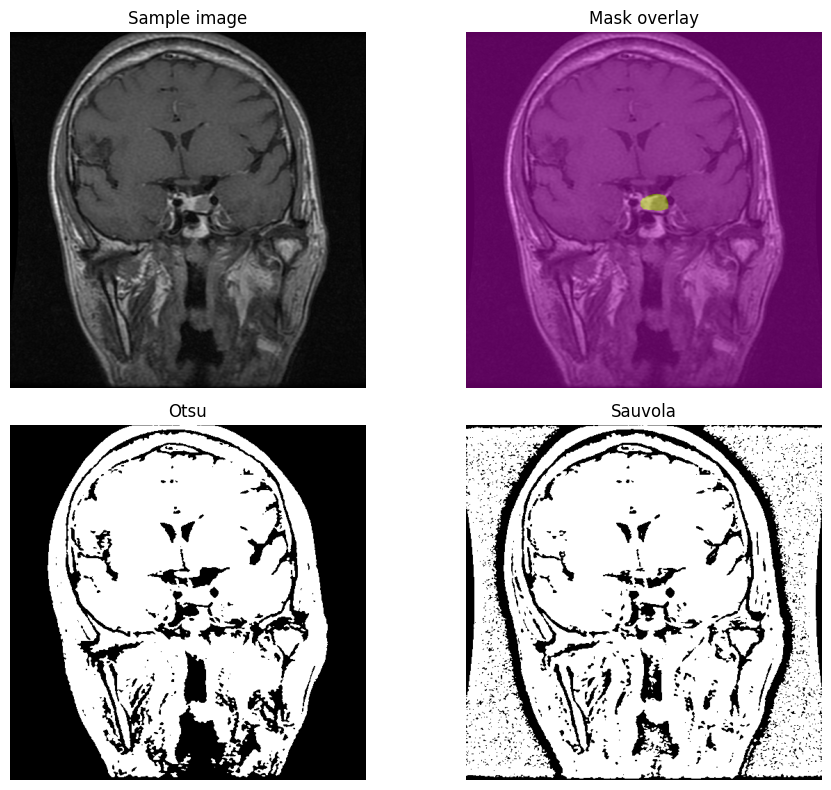

In [ ]:
import matplotlib.pyplot as plt

rng = random.Random(21)
sample_img, sample_mask = rng.choice(pairs)
img = load_gray(sample_img)
mask = load_mask(sample_mask, size=(img.shape[1], img.shape[0]))
pred_otsu = segment_otsu(img)
pred_sauv = segment_sauvola(img)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Sample image")
axes[0].axis("off")

axes[1].imshow(img, cmap="gray")
axes[1].imshow(mask, cmap="spring", alpha=0.35)
axes[1].set_title("Mask overlay")
axes[1].axis("off")

axes[2].imshow(pred_otsu, cmap="gray")
axes[2].set_title("Otsu")
axes[2].axis("off")

axes[3].imshow(pred_sauv, cmap="gray")
axes[3].set_title("Sauvola")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## Evaluation
We compute Dice and Jaccard on a deterministic subset to compare global vs adaptive thresholding.

In [ ]:
dice_otsu, jacc_otsu = [], []
dice_sauv, jacc_sauv = [], []

for img_path, mask_path in pairs:
    gray = load_gray(img_path)
    gt = load_mask(mask_path, size=(gray.shape[1], gray.shape[0]))
    pred_otsu = segment_otsu(gray)
    pred_sauv = segment_sauvola(gray)
    d, j = dice_jaccard(pred_otsu, gt)
    dice_otsu.append(d)
    jacc_otsu.append(j)
    d, j = dice_jaccard(pred_sauv, gt)
    dice_sauv.append(d)
    jacc_sauv.append(j)

print("Otsu")
print(f"  Dice mean: {np.mean(dice_otsu):.4f}")
print(f"  Jaccard mean: {np.mean(jacc_otsu):.4f}")

print("\nSauvola")
print(f"  Dice mean: {np.mean(dice_sauv):.4f}")
print(f"  Jaccard mean: {np.mean(jacc_sauv):.4f}")

Otsu
  Dice mean: 0.0707
  Jaccard mean: 0.0376

Sauvola
  Dice mean: 0.0395
  Jaccard mean: 0.0204
